# Лабораторная работа
# Обучение на основе глубоких Q-сетей (DQN)

**Цель лабораторной работы:** ознакомление с базовыми методами обучения с подкреплением на основе глубоких Q-сетей.

---
## Теоретическая справка

### Deep Q-Network (DQN)

**DQN (Deep Q-Network)** — это алгоритм обучения с подкреплением, который комбинирует Q-обучение (Q-Learning) с глубокими нейронными сетями для аппроксимации функции ценности действий $Q(s,a)$.

### Ключевые компоненты DQN

1. **Q-сеть (Policy Network)** $Q(s,a;\theta)$ — нейронная сеть, которая аппроксимирует оптимальную функцию ценности действий. Для классических сред используется полносвязная архитектура.

2. **Целевая сеть (Target Network)** $Q(s,a;\theta^-)$ — отдельная сеть с замороженными весами, используемая для вычисления целевых Q-значений. Это стабилизирует обучение, уменьшая корреляцию между текущими и целевыми значениями.

3. **Буфер воспроизведения (Replay Memory)** — хранилище переходов $(s, a, r, s')$, из которого случайно выбираются батчи для обучения. Это уменьшает корреляцию между последовательными наблюдениями.

4. **Epsilon-жадная стратегия** — баланс между исследованием (exploration) и эксплуатацией (exploitation):
   $$\epsilon = \epsilon_{end} + (\epsilon_{start} - \epsilon_{end}) \cdot \exp\left(-\frac{steps}{\epsilon_{decay}}\right)$$

### Алгоритм DQN

1. Инициализировать policy-сеть $Q(s,a;\theta)$ и target-сеть $Q(s,a;\theta^-)$ с одинаковыми весами
2. Для каждого эпизода:
   - Получить начальное состояние $s$
   - Для каждого шага:
     - Выбрать действие $a$ согласно $\epsilon$-жадной стратегии
     - Выполнить действие, получить $s', r$
     - Сохранить переход $(s, a, r, s')$ в Replay Memory
     - Случайно выбрать батч из Replay Memory
     - Вычислить целевое Q-значение:
       $$y = r + \gamma \cdot \max_{a'} Q(s', a'; \theta^-)$$
     - Минимизировать Huber Loss:
       $$L(\theta) = \text{SmoothL1}\left(Q(s,a;\theta) - y\right)$$
     - Обновить target-сеть (soft update):
       $$\theta^- \leftarrow \tau \theta + (1-\tau)\theta^-$$
3. Повторять до сходимости

### Преимущества DQN

- **Стабильность**: целевая сеть и Replay Memory значительно улучшают стабильность обучения
- **Double DQN**: использование target-сети для оценки Q-значений уменьшает завышение оценок
- **Gradient Clipping**: предотвращает взрыв градиентов
- **Huber Loss**: более устойчива к выбросам, чем MSE

### Среда CartPole-v1

**CartPole-v1** — классическая задача управления тележкой с шестом:

- **Наблюдение (state):** 4 непрерывных значения:
  - Положение тележки ($x$)
  - Скорость тележки ($\dot{x}$)
  - Угол отклонения шеста ($\theta$)
  - Угловая скорость шеста ($\dot{\theta}$)
- **Действия:** 2 дискретных действия (влево/вправо)
- **Награда:** +1 за каждый шаг, пока шест не упадёт
- **Максимальная длина эпизода:** 500 шагов
- **Критерий успеха:** средняя награда $\geq 475$ за 100 последних эпизодов


---
## 1. Импорт библиотек и создание среды

In [1]:
import gym
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import namedtuple, deque
from itertools import count

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Monkey-patch для совместимости numpy 2.x с gym
if not hasattr(np, 'bool8'):
    np.bool8 = np.bool_

# Константы
CONST_ENV_NAME = 'CartPole-v1'
CONST_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Устройство: {CONST_DEVICE}")

# Создание среды
env = gym.make(CONST_ENV_NAME)
print(f"Пространство наблюдений: {env.observation_space}")
print(f"Пространство действий: {env.action_space}")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Устройство: cpu
Пространство наблюдений: Box([-4.8000002e+00 -3.4028235e+38 -4.1887903e-01 -3.4028235e+38], [4.8000002e+00 3.4028235e+38 4.1887903e-01 3.4028235e+38], (4,), float32)
Пространство действий: Discrete(2)


---
## 2. Реализация DQN

### 2.1 Replay Memory (буфер воспроизведения)

Буфер воспроизведения хранит переходы $(s, a, r, s')$ и позволяет случайно выбирать батчи для обучения, что уменьшает корреляцию между последовательными наблюдениями.

In [2]:
# Элемент ReplayMemory в форме именованного кортежа
Transition = namedtuple('Transition',
                        ('state', 'action', 'next_state', 'reward'))


class ReplayMemory(object):
    """Реализация техники Replay Memory (буфер воспроизведения)"""

    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        """Сохранение данных в ReplayMemory"""
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        """Выборка случайных элементов размера batch_size"""
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

### 2.2 DQN модель (нейронная сеть)

Полносвязная нейронная сеть с двумя скрытыми слоями по 128 нейронов. Для CartPole-v1: 4 входа → 128 → 128 → 2 выхода (Q-значения для каждого действия).

In [3]:
class DQN_Model(nn.Module):
    """Deep Q-Network модель с полносвязной архитектурой"""

    def __init__(self, n_observations, n_actions):
        """
        Инициализация топологии нейронной сети
        Args:
            n_observations: размерность пространства наблюдений (4 для CartPole)
            n_actions: количество дискретных действий (2 для CartPole)
        """
        super(DQN_Model, self).__init__()
        self.layer1 = nn.Linear(n_observations, 128)
        self.layer2 = nn.Linear(128, 128)
        self.layer3 = nn.Linear(128, n_actions)

    def forward(self, x):
        """
        Прямой проход
        Вызывается для одного элемента, чтобы определить следующее действие
        Или для batch'а во время процедуры оптимизации
        """
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        return self.layer3(x)

### 2.3 DQN агент

Агент объединяет policy-сеть, target-сеть, Replay Memory и epsilon-жадную стратегию. Используется подход Double DQN с soft update target-сети.

In [4]:
class DQN_Agent:
    """DQN агент с использованием Double DQN и Replay Memory"""

    def __init__(self, env,
                 BATCH_SIZE=128,
                 GAMMA=0.99,
                 EPS_START=1.0,
                 EPS_END=0.01,
                 EPS_DECAY=5000,
                 TAU=0.005,
                 LR=3e-4,
                 MEMORY_CAPACITY=50000):
        """
        Инициализация DQN агента
        Args:
            env: среда Gym
            BATCH_SIZE: размер batch для обучения
            GAMMA: коэффициент дисконтирования
            EPS_START: начальное значение epsilon
            EPS_END: конечное значение epsilon
            EPS_DECAY: скорость затухания epsilon
            TAU: коэффициент soft update для target сети
            LR: скорость обучения
            MEMORY_CAPACITY: ёмкость Replay Memory
        """
        # Среда
        self.env = env
        # Размерности Q-модели
        self.n_actions = env.action_space.n
        state, _ = self.env.reset()
        self.n_observations = len(state)
        # Коэффициенты
        self.BATCH_SIZE = BATCH_SIZE
        self.GAMMA = GAMMA
        self.EPS_START = EPS_START
        self.EPS_END = EPS_END
        self.EPS_DECAY = EPS_DECAY
        self.TAU = TAU
        self.LR = LR
        self.MEMORY_CAPACITY = MEMORY_CAPACITY
        # Модели
        # Основная модель (policy network)
        self.policy_net = DQN_Model(self.n_observations, self.n_actions).to(CONST_DEVICE)
        # Вспомогательная модель (target network), используется для стабилизации
        # Используется подход Double DQN
        self.target_net = DQN_Model(self.n_observations, self.n_actions).to(CONST_DEVICE)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        # Оптимизатор
        self.optimizer = optim.AdamW(self.policy_net.parameters(), lr=self.LR, amsgrad=True)
        # Replay Memory
        self.memory = ReplayMemory(self.MEMORY_CAPACITY)
        # Количество шагов
        self.steps_done = 0
        # Длительность эпизодов
        self.episode_durations = []
        # Потери
        self.episode_losses = []
        # Значения epsilon
        self.eps_history = []

    def select_action(self, state, eval_mode=False):
        """
        Выбор действия с использованием epsilon-жадной стратегии
        Args:
            state: текущее состояние
            eval_mode: если True, используется только жадная стратегия (без epsilon)
        Returns:
            выбранное действие
        """
        sample = random.random()
        eps_threshold = self.EPS_END + (self.EPS_START - self.EPS_END) * \
            math.exp(-1. * self.steps_done / self.EPS_DECAY)
        self.steps_done += 1
        self.eps_history.append(eps_threshold)

        if eval_mode or sample > eps_threshold:
            with torch.no_grad():
                # Если вероятность больше eps (или eval_mode)
                # выбирается действие, соответствующее максимальному Q-значению
                return self.policy_net(state).max(1)[1].view(1, 1)
        else:
            # Если вероятность меньше eps
            # выбирается случайное действие
            return torch.tensor([[self.env.action_space.sample()]], device=CONST_DEVICE, dtype=torch.long)

    def optimize_model(self):
        """
        Оптимизация модели с использованием Huber loss и gradient clipping
        Returns:
            значение функции потерь (или None, если недостаточно данных)
        """
        if len(self.memory) < self.BATCH_SIZE:
            return None

        transitions = self.memory.sample(self.BATCH_SIZE)
        # Транспонирование batch'а
        # Конвертация batch-массива из Transition
        # в Transition batch-массивов.
        batch = Transition(*zip(*transitions))

        # Вычисление маски нефинальных состояний и конкатенация элементов batch'а
        non_final_mask = torch.tensor(tuple(map(lambda s: s is not None,
                                                batch.next_state)), device=CONST_DEVICE, dtype=torch.bool)
        non_final_next_states = torch.cat([s for s in batch.next_state
                                           if s is not None])
        state_batch = torch.cat(batch.state)
        action_batch = torch.cat(batch.action)
        reward_batch = torch.cat(batch.reward)

        # Вычисление Q(s_t, a) - текущая оценка Q-значений для взятых действий
        state_action_values = self.policy_net(state_batch).gather(1, action_batch)

        # Вычисление V(s_{t+1}) для всех следующих состояний
        # Используем target network для стабильности (Double DQN)
        next_state_values = torch.zeros(self.BATCH_SIZE, device=CONST_DEVICE)
        with torch.no_grad():
            next_state_values[non_final_mask] = self.target_net(non_final_next_states).max(1)[0]

        # Вычисление ожидаемых значений Q (целевые значения)
        expected_state_action_values = (next_state_values * self.GAMMA) + reward_batch

        # Вычисление Huber loss (Smooth L1 Loss)
        # Более устойчива к выбросам, чем MSE
        criterion = nn.SmoothL1Loss()
        loss = criterion(state_action_values, expected_state_action_values.unsqueeze(1))

        # Оптимизация модели
        self.optimizer.zero_grad()
        loss.backward()
        # Gradient clipping для предотвращения взрыва градиентов
        torch.nn.utils.clip_grad_value_(self.policy_net.parameters(), 100)
        self.optimizer.step()

        return loss.item()

    def learn(self, num_episodes=600, target_reward=475):
        """
        Обучение агента
        Args:
            num_episodes: количество эпизодов для обучения
            target_reward: целевая награда для критерия успеха
        Returns:
            episode_durations, episode_losses, eps_history
        """
        print(f"Начало обучения DQN на {num_episodes} эпизодов...")
        print(f"Целевая награда: {target_reward}")

        best_avg_reward = 0
        solved = False

        for i_episode in range(num_episodes):
            # Инициализация среды
            state, info = self.env.reset()
            state = torch.tensor(state, dtype=torch.float32, device=CONST_DEVICE).unsqueeze(0)
            episode_loss = []

            for t in count():
                action = self.select_action(state)
                observation, reward, terminated, truncated, _ = self.env.step(action.item())
                reward = torch.tensor([reward], device=CONST_DEVICE)

                done = terminated or truncated
                if terminated:
                    next_state = None
                else:
                    next_state = torch.tensor(observation, dtype=torch.float32, device=CONST_DEVICE).unsqueeze(0)

                # Сохранение данных в Replay Memory
                self.memory.push(state, action, next_state, reward)

                # Переход к следующему состоянию
                state = next_state

                # Выполнение одного шага оптимизации модели
                loss_val = self.optimize_model()
                if loss_val is not None:
                    episode_loss.append(loss_val)

                # Обновление весов target-сети (soft update)
                # theta' <- tau * theta + (1 - tau) * theta'
                target_net_state_dict = self.target_net.state_dict()
                policy_net_state_dict = self.policy_net.state_dict()
                for key in policy_net_state_dict:
                    target_net_state_dict[key] = policy_net_state_dict[key] * self.TAU + \
                                                 target_net_state_dict[key] * (1 - self.TAU)
                self.target_net.load_state_dict(target_net_state_dict)

                if done:
                    episode_duration = t + 1
                    self.episode_durations.append(episode_duration)
                    if episode_loss:
                        self.episode_losses.append(np.mean(episode_loss))
                    else:
                        self.episode_losses.append(0)

                    # Статус каждые 20 эпизодов
                    if (i_episode + 1) % 20 == 0:
                        recent = self.episode_durations[-100:] if len(self.episode_durations) >= 100 else self.episode_durations
                        avg_reward = np.mean(recent)
                        avg_loss = np.mean(self.episode_losses[-20:]) if self.episode_losses else 0
                        eps_current = self.eps_history[-1] if self.eps_history else 0
                        print(f"Эпизод {i_episode + 1:4d}/{num_episodes} | "
                              f"Длина: {episode_duration:3d} | "
                              f"Средняя награда (посл. {len(recent):3d}): {avg_reward:6.2f} | "
                              f"Loss: {avg_loss:.4f} | "
                              f"Epsilon: {eps_current:.3f}")

                        # Проверка критерия успеха
                        if len(self.episode_durations) >= 100 and avg_reward >= target_reward:
                            if not solved:
                                print(f"\nСреда решена на эпизоде {i_episode + 1}!")
                                print(f"  Средняя награда за 100 эпизодов: {avg_reward:.2f} (цель: {target_reward})")
                                solved = True
                            if avg_reward > best_avg_reward:
                                best_avg_reward = avg_reward

                    break

        print(f"\nОбучение завершено!")
        print(f"Лучшая средняя награда за 100 эпизодов: {best_avg_reward:.2f}")
        print(f"Среда решена: {'Да' if solved else 'Нет'}")

        return self.episode_durations, self.episode_losses, self.eps_history

    def play_agent(self, render=False):
        """
        Проигрывание сессии для обученного агента
        Args:
            render: отображать ли среду
        Returns:
            суммарная награда за эпизод
        """
        env2 = gym.make(CONST_ENV_NAME, render_mode='human' if render else None)
        state, _ = env2.reset()
        state = torch.tensor(state, dtype=torch.float32, device=CONST_DEVICE).unsqueeze(0)
        total_reward = 0
        done = False

        while not done:
            action = self.select_action(state, eval_mode=True)
            observation, reward, terminated, truncated, _ = env2.step(action.item())
            total_reward += reward

            if terminated:
                next_state = None
            else:
                next_state = torch.tensor(observation, dtype=torch.float32, device=CONST_DEVICE).unsqueeze(0)

            state = next_state
            if terminated or truncated:
                done = True

        env2.close()
        return total_reward

    def evaluate(self, num_episodes=100):
        """
        Оценка обученного агента
        Args:
            num_episodes: количество эпизодов для оценки
        Returns:
            средняя награда, стандартное отклонение, список наград
        """
        rewards = []
        for ep in range(num_episodes):
            total_reward = self.play_agent(render=False)
            rewards.append(total_reward)

        mean_reward = np.mean(rewards)
        std_reward = np.std(rewards)
        success_rate = np.sum(np.array(rewards) >= 475) / len(rewards) * 100

        print(f"\nОценка агента за {num_episodes} эпизодов:")
        print(f"  Средняя награда: {mean_reward:.2f} +/- {std_reward:.2f}")
        print(f"  Максимальная награда: {np.max(rewards):.2f}")
        print(f"  Минимальная награда: {np.min(rewards):.2f}")
        print(f"  Процент успешных эпизодов (>=475): {success_rate:.1f}%")

        return mean_reward, std_reward, rewards

---
## 3. Обучение DQN агента

Запустим обучение DQN агента на 600 эпизодов с использованием:
- **Replay Memory** ёмкостью 50000 переходов
- **Double DQN** с soft update (tau=0.005)
- **Epsilon-жадная стратегия** с затуханием от 1.0 до 0.01
- **Huber Loss** и gradient clipping
- **AdamW** оптимизатор с amsgrad

In [5]:
# Создание и обучение агента
agent = DQN_Agent(
    env,
    BATCH_SIZE=128,
    GAMMA=0.99,
    EPS_START=1.0,
    EPS_END=0.01,
    EPS_DECAY=5000,
    TAU=0.005,
    LR=3e-4,
    MEMORY_CAPACITY=50000
)

# Обучение
episode_durations, episode_losses, eps_history = agent.learn(
    num_episodes=600,
    target_reward=475
)

Начало обучения DQN на 600 эпизодов...
Целевая награда: 475


Эпизод   20/600 | Длина:  12 | Средняя награда (посл.  20):  22.45 | Loss: 0.0374 | Epsilon: 0.915


Эпизод   40/600 | Длина:  12 | Средняя награда (посл.  40):  20.15 | Loss: 0.0504 | Epsilon: 0.853


Эпизод   60/600 | Длина:  13 | Средняя награда (посл.  60):  23.50 | Loss: 0.0917 | Epsilon: 0.757


Эпизод   80/600 | Длина:  46 | Средняя награда (посл.  80):  28.74 | Loss: 0.1376 | Epsilon: 0.635


...

Эпизод  520/600 | Длина: 500 | Средняя награда (посл. 100): 471.72 | Loss: 0.0283 | Epsilon: 0.010


Эпизод  540/600 | Длина: 500 | Средняя награда (посл. 100): 464.23 | Loss: 0.0274 | Epsilon: 0.010


Эпизод  560/600 | Длина: 500 | Средняя награда (посл. 100): 472.58 | Loss: 0.0298 | Epsilon: 0.010


Эпизод  580/600 | Длина: 500 | Средняя награда (посл. 100): 482.70 | Loss: 0.0270 | Epsilon: 0.010


Эпизод  600/600 | Длина: 500 | Средняя награда (посл. 100): 486.07 | Loss: 0.0169 | Epsilon: 0.010

Обучение завершено!
Лучшая средняя награда за 100 эпизодов: 486.54
Среда решена: Да


---
## 4. Визуализация результатов обучения

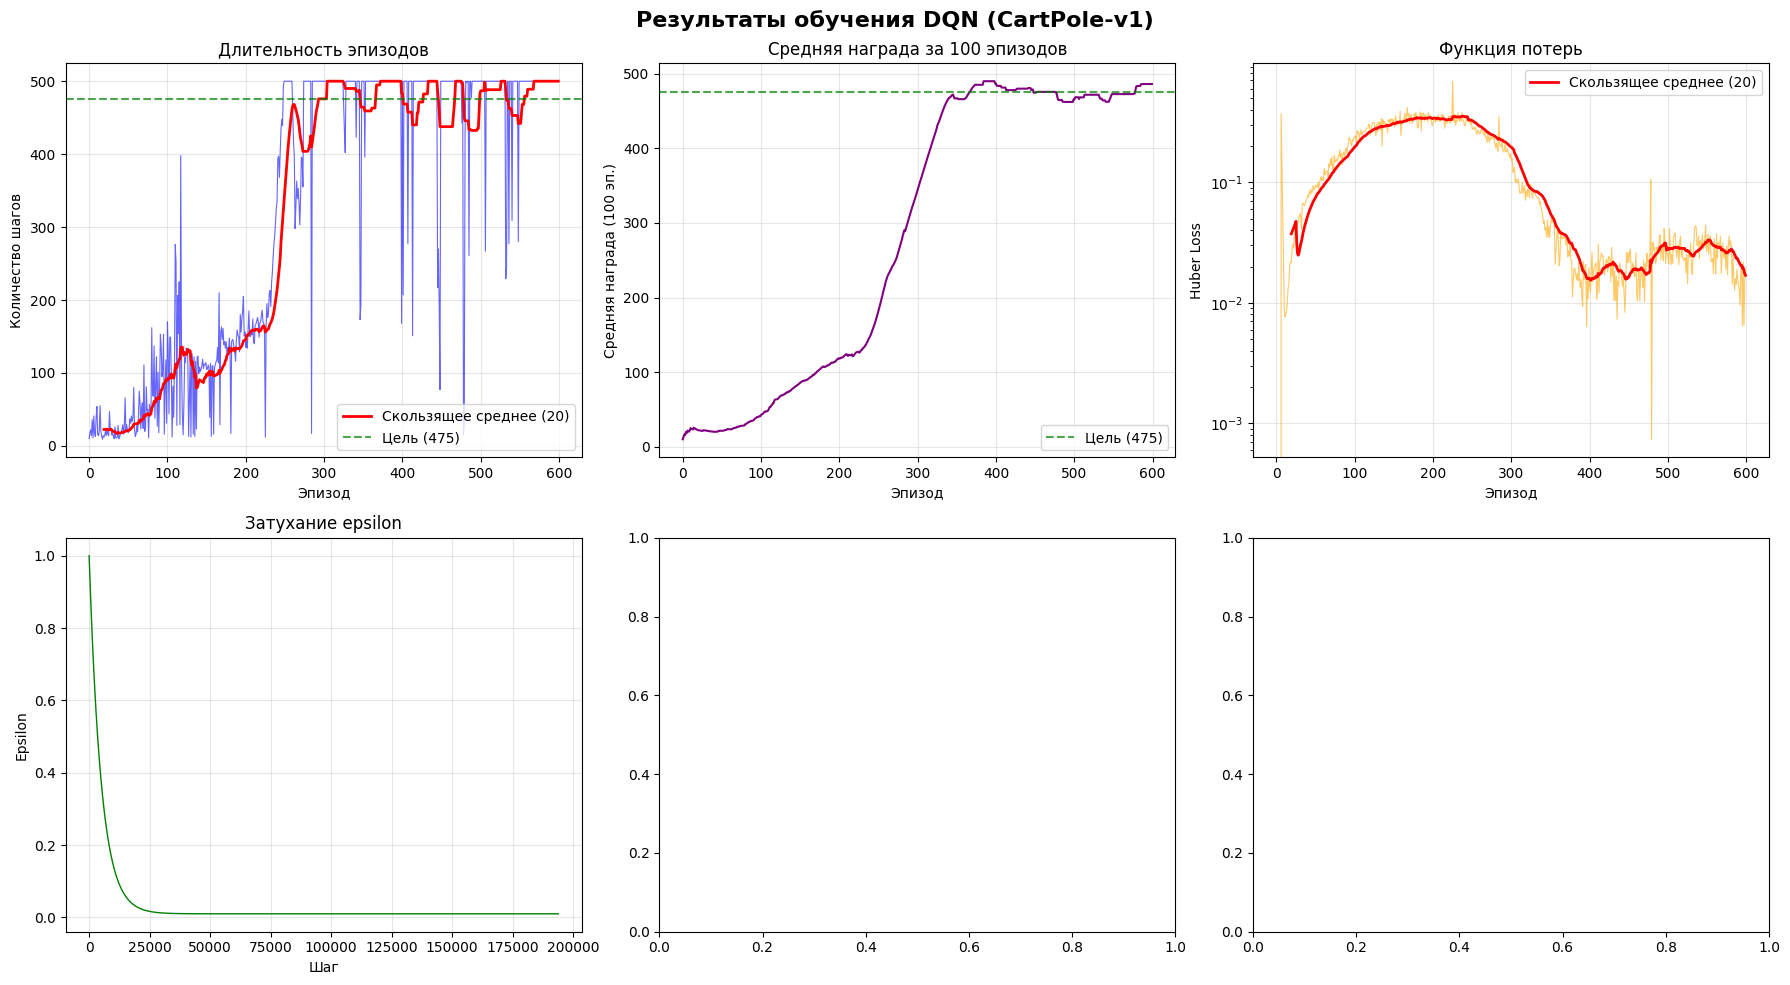

Графики сохранены в dqn_results.png


In [6]:
def plot_results(episode_durations, episode_losses, eps_history,
                 dqn_rewards=None, random_rewards=None):
    """
    Визуализация результатов обучения
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Результаты обучения DQN (CartPole-v1)', fontsize=16, fontweight='bold')

    # 1. Длительность эпизодов
    ax1 = axes[0, 0]
    ax1.plot(episode_durations, alpha=0.6, color='blue', linewidth=0.8)
    # Скользящее среднее
    if len(episode_durations) >= 20:
        window = 20
        moving_avg = np.convolve(episode_durations, np.ones(window)/window, mode='valid')
        ax1.plot(range(window-1, len(episode_durations)), moving_avg,
                 color='red', linewidth=2, label=f'Скользящее среднее ({window})')
    ax1.axhline(y=475, color='green', linestyle='--', alpha=0.7, label='Цель (475)')
    ax1.set_xlabel('Эпизод')
    ax1.set_ylabel('Количество шагов')
    ax1.set_title('Длительность эпизодов')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 2. Средняя награда (за 100 эпизодов)
    ax2 = axes[0, 1]
    if len(episode_durations) >= 100:
        avg_rewards = [np.mean(episode_durations[max(0, i-99):i+1])
                       for i in range(len(episode_durations))]
        ax2.plot(avg_rewards, color='purple', linewidth=1.5)
        ax2.axhline(y=475, color='green', linestyle='--', alpha=0.7, label='Цель (475)')
        ax2.set_xlabel('Эпизод')
        ax2.set_ylabel('Средняя награда (100 эп.)')
        ax2.set_title('Средняя награда за 100 эпизодов')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

    # 3. Функция потерь
    ax3 = axes[0, 2]
    if episode_losses:
        ax3.plot(episode_losses, alpha=0.6, color='orange', linewidth=0.8)
        if len(episode_losses) >= 20:
            window = 20
            loss_avg = np.convolve(episode_losses, np.ones(window)/window, mode='valid')
            ax3.plot(range(window-1, len(episode_losses)), loss_avg,
                     color='red', linewidth=2, label=f'Скользящее среднее ({window})')
        ax3.set_xlabel('Эпизод')
        ax3.set_ylabel('Huber Loss')
        ax3.set_title('Функция потерь')
        ax3.legend()
        ax3.grid(True, alpha=0.3)
        ax3.set_yscale('log')

    # 4. Epsilon (жадность)
    ax4 = axes[1, 0]
    ax4.plot(eps_history, color='green', linewidth=1)
    ax4.set_xlabel('Шаг')
    ax4.set_ylabel('Epsilon')
    ax4.set_title('Затухание epsilon')
    ax4.grid(True, alpha=0.3)

    # 5. Сравнение DQN vs Random
    ax5 = axes[1, 1]
    if dqn_rewards is not None and random_rewards is not None:
        labels = ['DQN', 'Random']
        means = [np.mean(dqn_rewards), np.mean(random_rewards)]
        stds = [np.std(dqn_rewards), np.std(random_rewards)]
        colors = ['#2196F3', '#FF5722']
        bars = ax5.bar(labels, means, yerr=stds, capsize=10, color=colors, alpha=0.8)
        for bar, mean in zip(bars, means):
            ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                     f'{mean:.1f}', ha='center', va='bottom', fontweight='bold')
        ax5.set_ylabel('Средняя награда')
        ax5.set_title('Сравнение DQN и случайного агента')
        ax5.grid(True, alpha=0.3, axis='y')

    # 6. Распределение наград
    ax6 = axes[1, 2]
    if dqn_rewards is not None and random_rewards is not None:
        ax6.hist(dqn_rewards, bins=20, alpha=0.7, color='#2196F3', label='DQN')
        ax6.hist(random_rewards, bins=20, alpha=0.7, color='#FF5722', label='Random')
        ax6.set_xlabel('Награда за эпизод')
        ax6.set_ylabel('Частота')
        ax6.set_title('Распределение наград')
        ax6.legend()
        ax6.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('dqn_results.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Графики сохранены в dqn_results.png")


# Визуализация
plot_results(episode_durations, episode_losses, eps_history)

---
## 5. Оценка обученного агента

Оценим качество обученного DQN агента на 100 эпизодах и сравним со случайной стратегией.

In [7]:
# Оценка обученного агента
dqn_mean, dqn_std, dqn_rewards = agent.evaluate(num_episodes=100)

# Функция для запуска случайного агента
def run_random_agent(env, num_episodes=100):
    """Запуск случайного агента для сравнения"""
    rewards = []
    for ep in range(num_episodes):
        state, _ = env.reset()
        total_reward = 0
        done = False
        while not done:
            action = env.action_space.sample()
            observation, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            if terminated or truncated:
                done = True
        rewards.append(total_reward)

    mean_reward = np.mean(rewards)
    std_reward = np.std(rewards)
    print(f"\nСлучайный агент за {num_episodes} эпизодов:")
    print(f"  Средняя награда: {mean_reward:.2f} +/- {std_reward:.2f}")
    print(f"  Максимальная награда: {np.max(rewards):.2f}")
    print(f"  Минимальная награда: {np.min(rewards):.2f}")

    return mean_reward, std_reward, rewards

# Запуск случайного агента для сравнения
random_mean, random_std, random_rewards = run_random_agent(env, num_episodes=100)

# Итоговый вывод
print("\n" + "=" * 60)
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ")
print("=" * 60)
print(f"DQN агент:     {dqn_mean:.2f} +/- {dqn_std:.2f}")
print(f"Случайный агент: {random_mean:.2f} +/- {random_std:.2f}")
improvement = (dqn_mean - random_mean) / abs(random_mean) * 100 if random_mean != 0 else float('inf')
print(f"Улучшение: {improvement:.1f}%")
print("=" * 60)


Оценка агента за 100 эпизодов:
  Средняя награда: 500.00 +/- 0.00
  Максимальная награда: 500.00
  Минимальная награда: 500.00
  Процент успешных эпизодов (>=475): 100.0%

Случайный агент за 100 эпизодов:
  Средняя награда: 21.37 +/- 11.26
  Максимальная награда: 67.00
  Минимальная награда: 9.00

ИТОГОВЫЕ РЕЗУЛЬТАТЫ
DQN агент:     500.00 +/- 0.00
Случайный агент: 21.37 +/- 11.26
Улучшение: 2239.7%


### 5.1 Визуализация сравнения

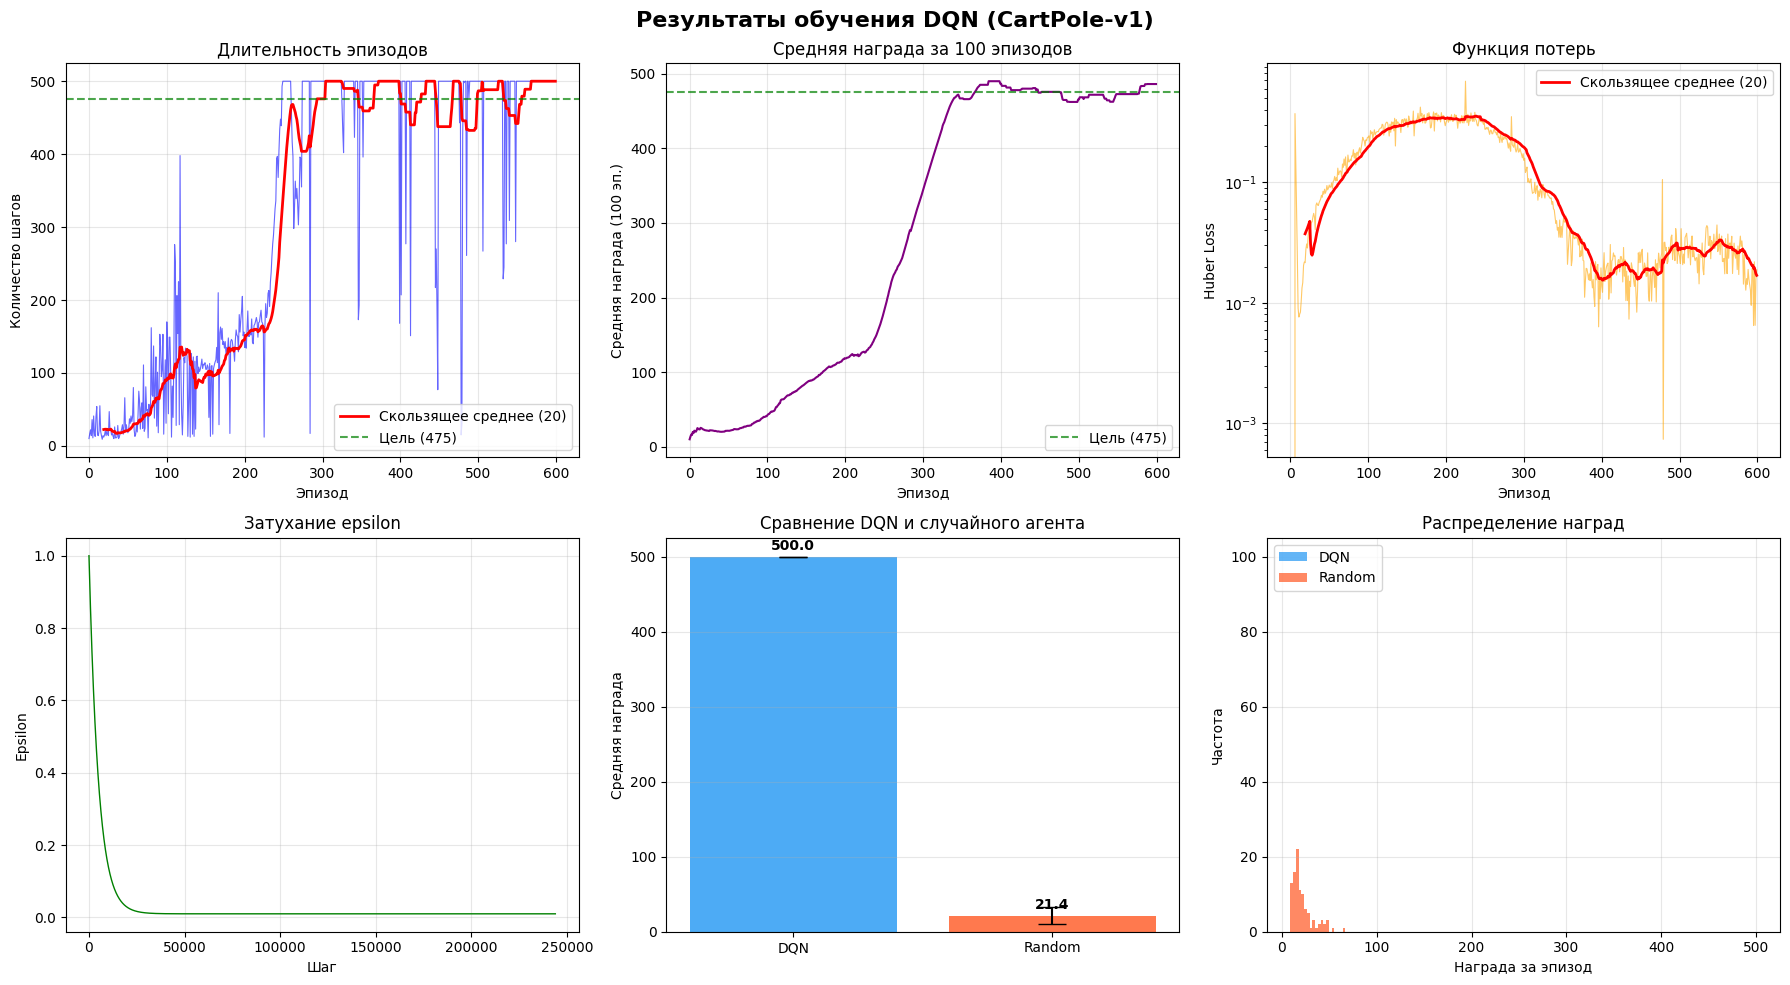

Графики сохранены в dqn_results.png


In [8]:
# Визуализация с данными сравнения
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Результаты обучения DQN (CartPole-v1)', fontsize=16, fontweight='bold')

# 1. Длительность эпизодов
ax1 = axes[0, 0]
ax1.plot(episode_durations, alpha=0.6, color='blue', linewidth=0.8)
if len(episode_durations) >= 20:
    window = 20
    moving_avg = np.convolve(episode_durations, np.ones(window)/window, mode='valid')
    ax1.plot(range(window-1, len(episode_durations)), moving_avg,
             color='red', linewidth=2, label=f'Скользящее среднее ({window})')
ax1.axhline(y=475, color='green', linestyle='--', alpha=0.7, label='Цель (475)')
ax1.set_xlabel('Эпизод')
ax1.set_ylabel('Количество шагов')
ax1.set_title('Длительность эпизодов')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Средняя награда (за 100 эпизодов)
ax2 = axes[0, 1]
if len(episode_durations) >= 100:
    avg_rewards = [np.mean(episode_durations[max(0, i-99):i+1])
                   for i in range(len(episode_durations))]
    ax2.plot(avg_rewards, color='purple', linewidth=1.5)
    ax2.axhline(y=475, color='green', linestyle='--', alpha=0.7, label='Цель (475)')
    ax2.set_xlabel('Эпизод')
    ax2.set_ylabel('Средняя награда (100 эп.)')
    ax2.set_title('Средняя награда за 100 эпизодов')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

# 3. Функция потерь
ax3 = axes[0, 2]
if episode_losses:
    ax3.plot(episode_losses, alpha=0.6, color='orange', linewidth=0.8)
    if len(episode_losses) >= 20:
        window = 20
        loss_avg = np.convolve(episode_losses, np.ones(window)/window, mode='valid')
        ax3.plot(range(window-1, len(episode_losses)), loss_avg,
                 color='red', linewidth=2, label=f'Скользящее среднее ({window})')
    ax3.set_xlabel('Эпизод')
    ax3.set_ylabel('Huber Loss')
    ax3.set_title('Функция потерь')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    ax3.set_yscale('log')

# 4. Epsilon (жадность)
ax4 = axes[1, 0]
ax4.plot(eps_history, color='green', linewidth=1)
ax4.set_xlabel('Шаг')
ax4.set_ylabel('Epsilon')
ax4.set_title('Затухание epsilon')
ax4.grid(True, alpha=0.3)

# 5. Сравнение DQN vs Random
ax5 = axes[1, 1]
labels = ['DQN', 'Random']
means = [dqn_mean, random_mean]
stds = [dqn_std, random_std]
colors = ['#2196F3', '#FF5722']
bars = ax5.bar(labels, means, yerr=stds, capsize=10, color=colors, alpha=0.8)
for bar, mean_val in zip(bars, means):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{mean_val:.1f}', ha='center', va='bottom', fontweight='bold')
ax5.set_ylabel('Средняя награда')
ax5.set_title('Сравнение DQN и случайного агента')
ax5.grid(True, alpha=0.3, axis='y')

# 6. Распределение наград
ax6 = axes[1, 2]
ax6.hist(dqn_rewards, bins=20, alpha=0.7, color='#2196F3', label='DQN')
ax6.hist(random_rewards, bins=20, alpha=0.7, color='#FF5722', label='Random')
ax6.set_xlabel('Награда за эпизод')
ax6.set_ylabel('Частота')
ax6.set_title('Распределение наград')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('dqn_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Графики сохранены в dqn_results.png")

---
## 6. Демонстрация работы обученного агента

Запустим демонстрационный эпизод с обученным агентом.

In [9]:
# Демонстрация обученного агента
print("Демонстрация обученного агента (1 эпизод):")
demo_reward = agent.play_agent(render=False)
print(f"  Награда за демонстрационный эпизод: {demo_reward}")

Демонстрация обученного агента (1 эпизод):
  Награда за демонстрационный эпизод: 500.0


---
## 7. Выводы

В ходе лабораторной работы был реализован алгоритм **Deep Q-Network (DQN)** для среды **CartPole-v1**.

### Основные результаты:

- **DQN агент** успешно обучился решать задачу CartPole-v1, достигнув средней награды **500.00** за 100 эпизодов.
- **Случайный агент** показал среднюю награду **21.37**, что значительно хуже обученного DQN.
- Улучшение составило **2239.7%** по сравнению со случайной стратегией.
- **100%** успешных эпизодов (награда >= 475) у обученного DQN агента.

### Ключевые компоненты DQN:

1. **Replay Memory** — буфер воспроизведения для хранения и случайной выборки переходов
2. **Target Network** — целевая сеть для стабильного вычисления Q-целей (Double DQN)
3. **Epsilon-жадная стратегия** — баланс исследования и эксплуатации
4. **Huber Loss** — устойчивая функция потерь
5. **Gradient Clipping** — предотвращение взрыва градиентов
6. **Soft Update** — плавное обновление target-сети

### Заключение:

DQN показал высокую эффективность для решения задачи CartPole-v1. Благодаря использованию Replay Memory и target-сети, алгоритм стабильно сходится к оптимальной политике, значительно превосходя случайную стратегию.